In [1]:
import sys
from unittest.mock import MagicMock
import time
import os
from unittest.mock import patch
try:
    import MetaTrader5
except ImportError:
    mt5 = MagicMock()
    mt5.TIMEFRAME_M5 = 5
    mt5.TIMEFRAME_M1 = 1
    sys.modules['MetaTrader5'] = mt5
    print('MetaTrader5 mocked successfully')

# Collecting Data - Preprocessing and Data Acquisition Test
This notebook tests the classes for data acquisition, technical indicator calculation, and preprocessing.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Add project root to path
sys.path.append(str(Path.cwd().parent))

from Collecting_Data.mt5data import MT5DataLoader
from Collecting_Data.Price import YFinanceDataLoader
from Collecting_Data.preproc_single_inout import SingleInOutPreprocessor
from Collecting_Data.preproc_multi_inout import MultiInOutPreprocessor
from Collecting_Data.preproc_pivot import PivotPreprocessor
from Collecting_Data.indicators import IndicatorEngine
from Collecting_Data.logging_config import setup_logging

# Setup logging for the notebook session
setup_logging(log_dir="../logs")


## 3. Test Indicator Engine (indicators.py)


In [3]:
# Create a dummy dataset for quick testing if real data is missing
n = 1000
np.random.seed(42)
prices = 1.2500 + np.cumsum(np.random.randn(n) * 0.0002)
df_dummy = pd.DataFrame({
    'Datetime': pd.date_range('2024-01-01', periods=n, freq='5min'),
    'Open': prices + np.random.randn(n) * 0.0001,
    'High': prices + np.abs(np.random.randn(n)) * 0.0003,
    'Low': prices - np.abs(np.random.randn(n)) * 0.0003,
    'Close': prices,
    'TickVolume': np.random.randint(100, 1000, n),
    'Spread': np.zeros(n)
})

engine = IndicatorEngine(dropna=True)
df_enriched = engine.calculate(df_dummy)
print(f"Enriched data shape: {df_enriched.shape}")
display(df_enriched.head(10))


2026-06-26 20:40:54,725 [INFO] IndicatorEngine: Dropped 0 rows containing NaN in EMA or ATR columns.


Enriched data shape: (1000, 32)


,Datetime,Open,High,Low,Close,TickVolume,Spread,ema_21,ema_50,ema_600,...,dist_ema_21,cross_ema_21,ema_span_21,dist_ema_50,cross_ema_50,ema_span_50,dist_ema_600,cross_ema_600,ema_span_600,ema_slope_600
0,2024-01-01 00:00:00,1.250239,1.250302,1.249527,1.250099,662,0.0,1.250099,1.250099,1.250099,...,0.000000,0,1,0.000000,0,1,0.000000,0,1,NaN
1,2024-01-01 00:05:00,1.250164,1.250115,1.249814,1.250072,365,0.0,1.250097,1.250098,1.250099,...,-0.033922,0,1,-0.035851,0,1,-0.037190,0,1,NaN
2,2024-01-01 00:10:00,1.250207,1.250439,1.250077,1.250201,219,0.0,1.250106,1.250102,1.250100,...,0.132854,1,1,0.138486,1,1,0.142274,1,1,NaN
3,2024-01-01 00:15:00,1.250441,1.250598,1.249940,1.250506,811,0.0,1.250143,1.250118,1.250101,...,0.511253,0,1,0.545765,0,1,0.569948,0,1,NaN
4,2024-01-01 00:20:00,1.250529,1.251027,1.250292,1.250459,347,0.0,1.250171,1.250131,1.250102,...,0.403846,0,0,0.459887,0,0,0.501107,0,0,NaN
5,2024-01-01 00:25:00,1.250452,1.250476,1.250012,1.250412,169,0.0,1.250193,1.250142,1.250103,...,0.315181,0,1,0.388317,0,1,0.444951,0,1,NaN
6,2024-01-01 00:30:00,1.250818,1.250728,1.250582,1.250728,952,0.0,1.250242,1.250165,1.250105,...,0.728309,0,0,0.842835,0,0,0.933048,0,0,NaN
7,2024-01-01 00:35:00,1.250945,1.251127,1.250417,1.250882,156,0.0,1.250300,1.250194,1.250108,...,0.867266,0,0,1.026125,0,0,1.153965,0,0,NaN
8,2024-01-01 00:40:00,1.250893,1.250985,1.250463,1.250788,481,0.0,1.250344,1.250217,1.250110,...,0.671689,0,0,0.864956,0,0,1.026718,0,0,NaN
9,2024-01-01 00:45:00,1.250843,1.251177,1.250755,1.250896,138,0.0,1.250395,1.250243,1.250113,...,0.780155,0,0,1.015099,0,0,1.218490,0,0,NaN


### 3.1 Visualization of New Indicators


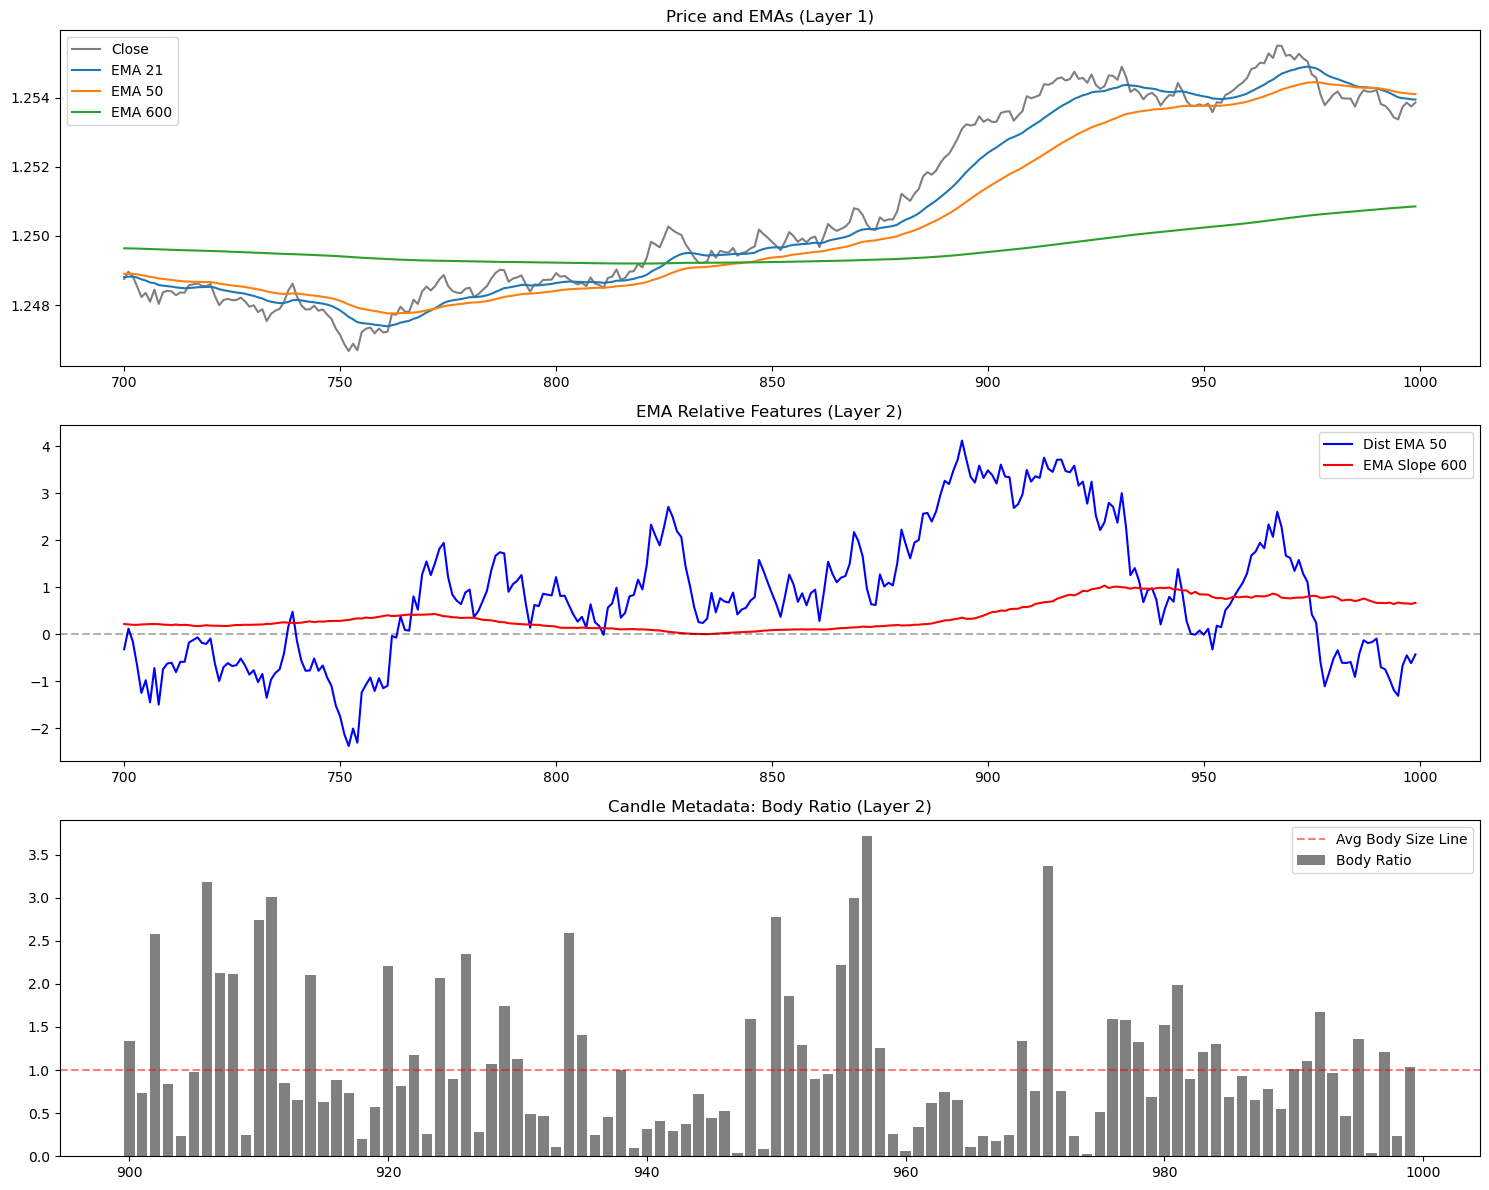

In [4]:
plt.figure(figsize=(15, 12))

# Subplot 1: Price and EMAs
plt.subplot(3, 1, 1)
plt.plot(df_enriched['Close'].tail(300), label='Close', color='black', alpha=0.5)
plt.plot(df_enriched['ema_21'].tail(300), label='EMA 21')
plt.plot(df_enriched['ema_50'].tail(300), label='EMA 50')
plt.plot(df_enriched['ema_600'].tail(300), label='EMA 600')
plt.title('Price and EMAs (Layer 1)')
plt.legend()

# Subplot 2: EMA Distance and Slope
plt.subplot(3, 1, 2)
plt.plot(df_enriched['dist_ema_50'].tail(300), label='Dist EMA 50', color='blue')
plt.plot(df_enriched['ema_slope_600'].tail(300), label='EMA Slope 600', color='red')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title('EMA Relative Features (Layer 2)')
plt.legend()

# Subplot 3: Candle Metadata (Body Ratio)
plt.subplot(3, 1, 3)
plt.bar(df_enriched.tail(100).index, df_enriched['body_vs_avg'].tail(100), label='Body Ratio', color='gray')
plt.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Avg Body Size Line')
plt.title('Candle Metadata: Body Ratio (Layer 2)')
plt.legend()

plt.tight_layout()
plt.show()


## 2. Test Data Loaders (mt5data.py & Price.py)


In [5]:
# Test YFinanceDataLoader
yf_loader = YFinanceDataLoader()
yf_df = yf_loader.download_data(period='1mo', interval='1h')
if yf_df is not None:
    print("YFinance data downloaded successfully.")
    display(yf_df.head())

# Test MT5DataLoader (Requires MT5 Terminal and credentials)
print("\nTesting MT5DataLoader (Mocked initialization test)...")
mt5_loader = MT5DataLoader()
print("MT5DataLoader initialized. (Real connection requires MT5 terminal)")


[*********************100%***********************]  1 of 1 completed

Data saved to C:\Users\MHossein\Documents\GitHub\Forex_DNN\Data\GBPUSD_1h.csv
YFinance data downloaded successfully.


Price,Datetime,Close,High,Low,Open,Volume
0,2026-05-26 17:00:00+00:00,1.344122,1.344809,1.343978,1.344194,0
1,2026-05-26 18:00:00+00:00,1.344538,1.344610,1.344050,1.344104,0
2,2026-05-26 19:00:00+00:00,1.344845,1.345008,1.344267,1.344393,0
3,2026-05-26 20:00:00+00:00,1.344773,1.345352,1.344538,1.345044,0
4,2026-05-26 21:00:00+00:00,1.345026,1.345316,1.344158,1.344881,0



Testing MT5DataLoader (Mocked initialization test)...
MT5DataLoader initialized. (Real connection requires MT5 terminal)


## 2.1 Test Unified Data Feed (data_feed.py)


In [7]:
from Collecting_Data.data_feed import MT5DataFeed, FeedHealth

print("Testing MT5DataFeed (Mocked)...")
feed = MT5DataFeed()

# Mock connect
with patch('MetaTrader5.initialize', return_value=True):
    success = feed.connect()
    print(f"Connect success: {success}")
    print(f"Health: {feed.health}")

# Mock health check
with patch('MetaTrader5.symbol_info_tick', return_value=MagicMock(time=time.time())):
    health = feed.check_health("EURUSD")
    print(f"Health after check: {health}")

feed.disconnect()


2026-06-26 20:41:03,845 [INFO] DataFeed: MT5 connected — None / (0, 0, '')
2026-06-26 20:41:03,847 [INFO] DataFeed: MT5 disconnected.


Testing MT5DataFeed (Mocked)...
login=91190435, password=Lord@7516, server=LiteFinance-MT5-Demo
Connect success: True
Health: FeedHealth.HEALTHY
Health after check: FeedHealth.HEALTHY


## 3. Test Preprocessors


In [8]:
# 3.1 SingleInOutPreprocessor
print("Testing SingleInOutPreprocessor...")
preproc_s = SingleInOutPreprocessor()
df_s = preproc_s.preprocess("GBPUSD_1h.csv")
if df_s is not None:
    print(f"Single InOut shape: {df_s.shape}")
    display(df_s.head())

# 3.2 MultiInOutPreprocessor
print("\nTesting MultiInOutPreprocessor...")
preproc_m = MultiInOutPreprocessor()
X, y = preproc_m.preprocess("GBPUSD_1h.csv", num_input_candles=24, num_output_candles=1)
if X is not None:
    print(f"Multi InOut shapes - X: {X.shape}, y: {y.shape}")

# 3.3 PivotPreprocessor
print("\nTesting PivotPreprocessor...")
preproc_p = PivotPreprocessor()
df_p = preproc_p.preprocess("GBPUSD_1h.csv")
if df_p is not None:
    print(f"Pivot data shape: {df_p.shape}")


2026-06-26 20:39:13,513 [WARNING] IndicatorEngine: Input DataFrame has fewer rows (549) than warmup requirement (632). Indicators may not be fully warmed up.
2026-06-26 20:39:13,531 [INFO] IndicatorEngine: Dropped 0 rows containing NaN in EMA or ATR columns.


Testing SingleInOutPreprocessor...
Single InOut shape: (516, 35)


,Open,High,Low,Close,Vol,TickVolume,Spread,ema_21,ema_50,ema_600,...,dist_ema_50,cross_ema_50,ema_span_50,dist_ema_600,cross_ema_600,ema_span_600,ema_slope_600,Price_Change,Binary_Label,Multi_Label
32,1.341256,1.341310,1.339818,1.339818,0,0,0,1.342926,1.343641,1.344097,...,-3.419183,0,0,-3.827140,0,0,0.022600,0.000359,1,3
33,1.340051,1.340680,1.340016,1.340177,0,0,0,1.342676,1.343505,1.344084,...,-3.025890,0,0,-3.552270,0,0,0.036094,-0.003243,0,0
34,1.340231,1.340285,1.336934,1.336934,0,0,0,1.342154,1.343247,1.344060,...,-5.008236,0,0,-5.653016,0,0,0.052270,0.000859,1,3
35,1.337023,1.337864,1.336881,1.337793,0,0,0,1.341758,1.343033,1.344039,...,-4.223750,0,0,-5.034399,0,0,0.071648,0.001523,1,4
36,1.337793,1.339621,1.337632,1.339316,0,0,0,1.341536,1.342888,1.344023,...,-2.759900,0,0,-3.637577,0,0,0.083144,0.001203,1,4


2026-06-26 20:39:13,549 [WARNING] IndicatorEngine: Input DataFrame has fewer rows (549) than warmup requirement (632). Indicators may not be fully warmed up.
2026-06-26 20:39:13,565 [INFO] IndicatorEngine: Dropped 0 rows containing NaN in EMA or ATR columns.



Testing MultiInOutPreprocessor...


2026-06-26 20:39:13,850 [WARNING] IndicatorEngine: Input DataFrame has fewer rows (549) than warmup requirement (632). Indicators may not be fully warmed up.
2026-06-26 20:39:13,864 [INFO] IndicatorEngine: Dropped 0 rows containing NaN in EMA or ATR columns.


Multi InOut shapes - X: (525, 24, 32), y: (525, 1)

Testing PivotPreprocessor...
Pivot data shape: (525, 36)


## 4. Visualizing Features


2026-06-26 20:39:15,071 [WARNING] IndicatorEngine: Input DataFrame has fewer rows (549) than warmup requirement (632). Indicators may not be fully warmed up.
2026-06-26 20:39:15,085 [INFO] IndicatorEngine: Dropped 0 rows containing NaN in EMA or ATR columns.


Pivot data shape: (525, 36)


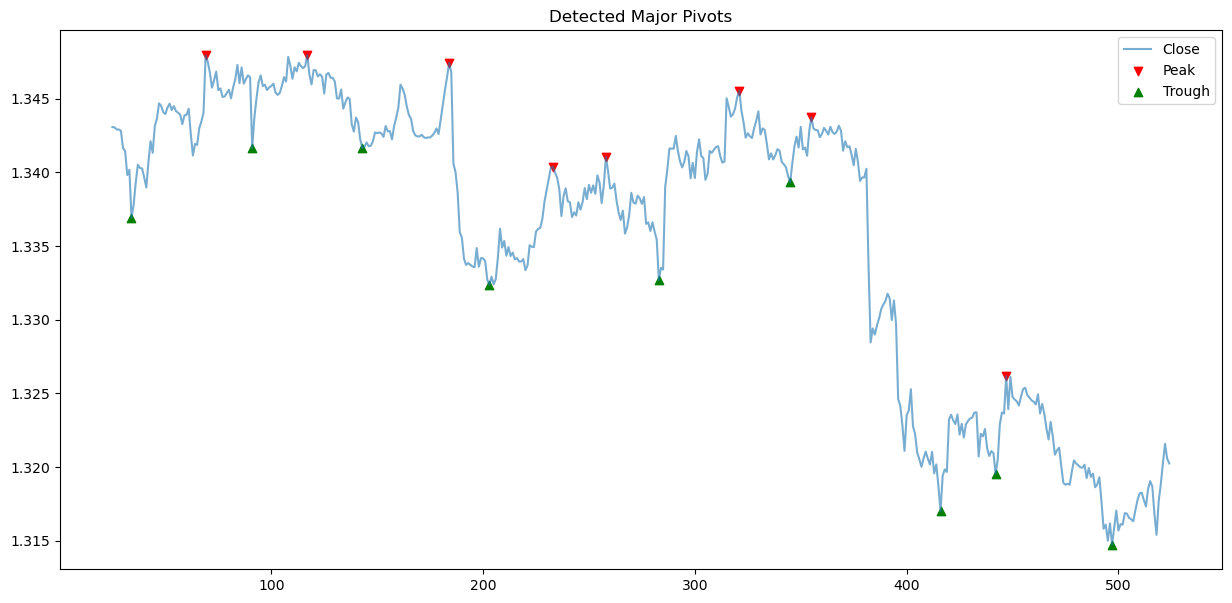

In [9]:
# Test PivotPreprocessor
pivot_preproc = PivotPreprocessor()
df_pivot = pivot_preproc.preprocess("GBPUSD_1h.csv")
if df_pivot is not None:
    print(f"Pivot data shape: {df_pivot.shape}")

    # Plot Pivots
    sample = df_pivot.tail(500)
    plt.figure(figsize=(15, 7))
    plt.plot(sample['Close'], label='Close', alpha=0.6)
    plt.scatter(sample[sample['Peak']==1].index, sample[sample['Peak']==1]['Close'], color='red', label='Peak', marker='v')
    plt.scatter(sample[sample['Trough']==1].index, sample[sample['Trough']==1]['Close'], color='green', label='Trough', marker='^')
    plt.title("Detected Major Pivots")
    plt.legend()
    plt.show()
else:
    print("Error: Pivot preprocessing failed (possibly file not found).")
